In [63]:
#imports 
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, random_split, Dataset

from torchvision import datasets, transforms

from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report
)

np.random.seed(42)
torch.manual_seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


In [64]:
data_dir = "./archive (1)"

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

train_full = datasets.ImageFolder(os.path.join(data_dir, "train"), transform=transform)
test_full  = datasets.ImageFolder(os.path.join(data_dir, "test"),  transform=transform)

selected_folders = [
    "air hockey",
    "baseball",
    "basketball",
    "bowling",
    "boxing",
    "cricket",
    "field hockey",
    "football",
    "swimming",
    "tennis",
]
class_names = selected_folders
num_classes = len(class_names)

# Get the original label IDs for the 10 selected folders
orig_ids = [train_full.class_to_idx[f] for f in selected_folders]
orig_to_new = {orig: new for new, orig in enumerate(orig_ids)}  # map to 0..9
print("orig_to_new mapping:", orig_to_new)

# Only keep samples whose original label is in our selected set
selected_label_ids = set(orig_ids)

train_indices = [
    i for i, (_, y) in enumerate(train_full.samples)
    if y in selected_label_ids
]
test_indices = [
    i for i, (_, y) in enumerate(test_full.samples)
    if y in selected_label_ids
]

train_subset_raw = Subset(train_full, train_indices)
test_subset_raw  = Subset(test_full,  test_indices)

# Wrap subset so that labels are remapped from original IDs → 0..9
class RemappedSubset(Dataset):
    def __init__(self, subset, label_map):
        self.subset = subset
        self.label_map = label_map

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        img, old_y = self.subset[idx]
        new_y = self.label_map[old_y]
        return img, new_y

train_data = RemappedSubset(train_subset_raw, orig_to_new)
test_data  = RemappedSubset(test_subset_raw,  orig_to_new)

batch_size = 64
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_data,  batch_size=batch_size, shuffle=False)

print("Train size:", len(train_data))
print("Test size:", len(test_data))

orig_to_new mapping: {0: 0, 7: 1, 8: 2, 14: 3, 15: 4, 21: 5, 26: 6, 31: 7, 85: 8, 87: 9}
Train size: 1456
Test size: 50


In [65]:
#flattening datasets 
def flatten_loader(loader):
    X_list, y_list = [], []
    for imgs, labels in loader:
        # imgs: (B, C, H, W) → (B, D)
        b = imgs.shape[0]
        arr = imgs.numpy().reshape(b, -1)
        X_list.append(arr)
        y_list.append(labels.numpy())
    X = np.vstack(X_list)
    y = np.hstack(y_list)
    return X, y

X_train, y_train = flatten_loader(train_loader)
X_test,  y_test  = flatten_loader(test_loader)

print("Train flattened:", X_train.shape)
print("Test flattened:",  X_test.shape)


Train flattened: (1456, 12288)
Test flattened: (50, 12288)


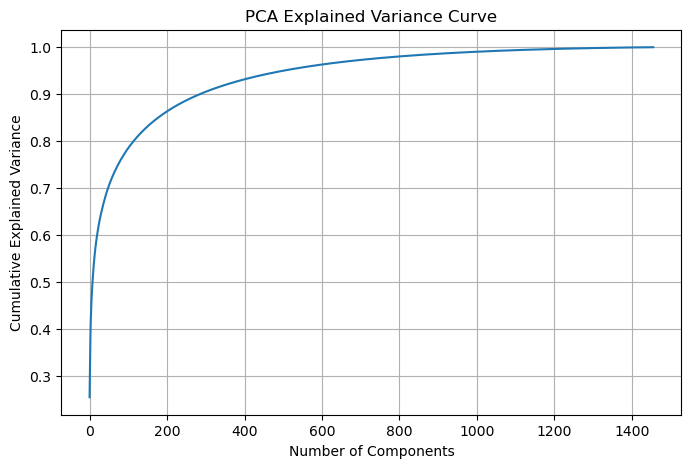

k for 90% variance: 286
k for 95% variance: 502
k for 99% variance: 991
k values to test: [30, 50, 75, 236, 286, 336, 452, 502, 552, 891, 991, 1091]


In [66]:
#pca
pca_full = PCA().fit(X_train)
explained_var = pca_full.explained_variance_ratio_
cumvar = np.cumsum(explained_var)

plt.figure(figsize=(8, 5))
plt.plot(cumvar)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance Curve")
plt.grid(True)
plt.show()

def find_k(threshold):
    """Return the smallest k such that cumulative variance ≥ threshold."""
    return int(np.argmax(cumvar >= threshold) + 1)

k90 = find_k(0.90)
k95 = find_k(0.95)
k99 = find_k(0.99)
print("k for 90% variance:", k90)
print("k for 95% variance:", k95)
print("k for 99% variance:", k99)

# Candidate k's: some fixed + variance-based ones
k_values = sorted(list({
    30, 50, 75,
    k90, k95, k99,
    max(5, k90 - 50), k90 + 50,
    max(5, k95 - 50), k95 + 50,
    max(5, k99 - 100), k99 + 100
}))
print("k values to test:", k_values)


In [67]:
#training logistic regression
results_pca = {}

for k in k_values:
    print("\nTesting PCA with k =", k)
    pca = PCA(n_components=k)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca  = pca.transform(X_test)

    clf = LogisticRegression(max_iter=3000)
    clf.fit(X_train_pca, y_train)
    preds = clf.predict(X_test_pca)

    acc = accuracy_score(y_test, preds)
    f1  = f1_score(y_test, preds, average="macro")
    results_pca[k] = {"acc": acc, "f1": f1}
    print(f"Accuracy: {acc:.4f}   F1 (macro): {f1:.4f}")

best_k = max(results_pca, key=lambda k: results_pca[k]["f1"])
print("\nBest PCA dimension selected:", best_k)
print("Best Accuracy:", results_pca[best_k]["acc"])
print("Best F1 Score:", results_pca[best_k]["f1"])



Testing PCA with k = 30
Accuracy: 0.5400   F1 (macro): 0.5324

Testing PCA with k = 50
Accuracy: 0.5400   F1 (macro): 0.5194

Testing PCA with k = 75
Accuracy: 0.5200   F1 (macro): 0.5172

Testing PCA with k = 236
Accuracy: 0.3800   F1 (macro): 0.3793

Testing PCA with k = 286
Accuracy: 0.3200   F1 (macro): 0.3204

Testing PCA with k = 336
Accuracy: 0.3400   F1 (macro): 0.3363

Testing PCA with k = 452
Accuracy: 0.4000   F1 (macro): 0.4110

Testing PCA with k = 502
Accuracy: 0.4200   F1 (macro): 0.4266

Testing PCA with k = 552
Accuracy: 0.4000   F1 (macro): 0.4218

Testing PCA with k = 891
Accuracy: 0.4400   F1 (macro): 0.4445

Testing PCA with k = 991
Accuracy: 0.4400   F1 (macro): 0.4488

Testing PCA with k = 1091
Accuracy: 0.4600   F1 (macro): 0.4692

Best PCA dimension selected: 30
Best Accuracy: 0.54
Best F1 Score: 0.5324170274170273


In [68]:
#final pca + regression model
print(f"\nTraining FINAL PCA model with k = {best_k}")
final_pca = PCA(n_components=best_k)
X_train_best = final_pca.fit_transform(X_train)
X_test_best  = final_pca.transform(X_test)

final_clf = LogisticRegression(max_iter=3000)
final_clf.fit(X_train_best, y_train)
pca_preds = final_clf.predict(X_test_best)

pca_acc = accuracy_score(y_test, pca_preds)
pca_f1  = f1_score(y_test, pca_preds, average="macro")
print("\nFINAL PCA+LR PERFORMANCE")
print("Accuracy:", pca_acc)
print("Macro F1:", pca_f1)

print("\nPer-class metrics (PCA+LR):")
print(classification_report(y_test, pca_preds, target_names=class_names))



Training FINAL PCA model with k = 30

FINAL PCA+LR PERFORMANCE
Accuracy: 0.56
Macro F1: 0.5466749916749917

Per-class metrics (PCA+LR):
              precision    recall  f1-score   support

  air hockey       0.50      0.80      0.62         5
    baseball       0.38      0.60      0.46         5
  basketball       0.44      0.80      0.57         5
     bowling       0.00      0.00      0.00         5
      boxing       1.00      0.80      0.89         5
     cricket       1.00      0.40      0.57         5
field hockey       1.00      0.60      0.75         5
    football       0.33      0.40      0.36         5
    swimming       0.80      0.80      0.80         5
      tennis       0.50      0.40      0.44         5

    accuracy                           0.56        50
   macro avg       0.60      0.56      0.55        50
weighted avg       0.60      0.56      0.55        50



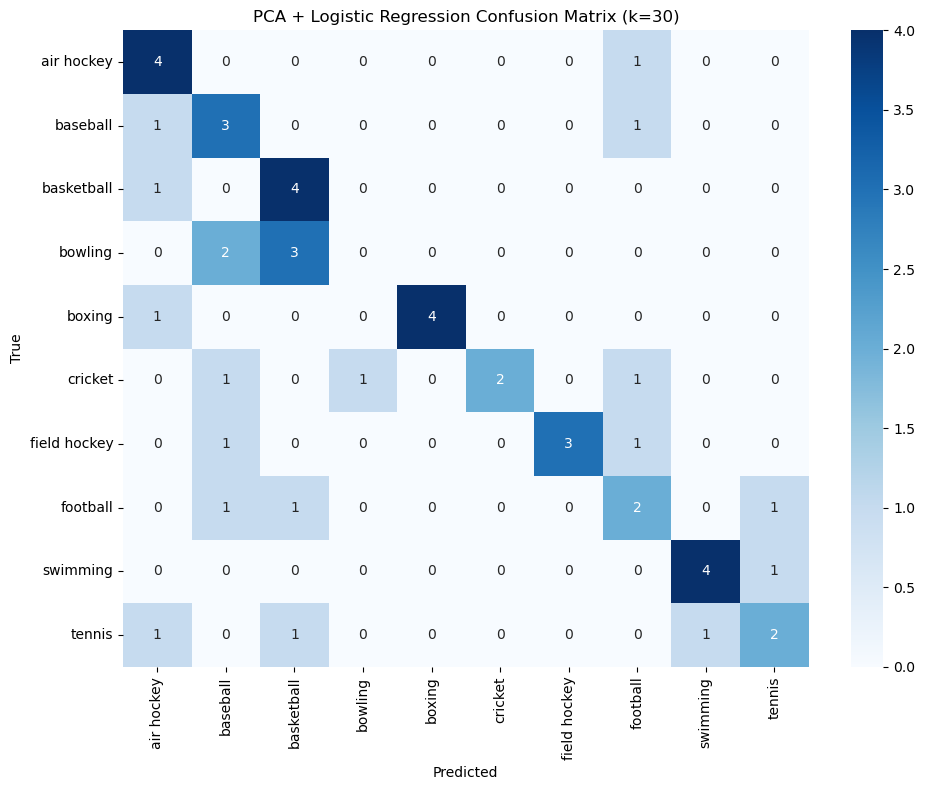

In [69]:
#confusion matrix
cm_pca = confusion_matrix(y_test, pca_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_pca, annot=True, fmt="d",
            cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"PCA + Logistic Regression Confusion Matrix (k={best_k})")
plt.tight_layout()
plt.show()


In [70]:
#train/test splitting
val_frac = 0.2
n_train = len(train_data)
n_val = int(val_frac * n_train)
n_main_train = n_train - n_val

cnn_train_data, cnn_val_data = random_split(
    train_data,
    [n_main_train, n_val],
    generator=torch.Generator().manual_seed(42)
)

cnn_train_loader = DataLoader(cnn_train_data, batch_size=batch_size, shuffle=True)
cnn_val_loader   = DataLoader(cnn_val_data,   batch_size=batch_size, shuffle=False)

print("CNN train size:", len(cnn_train_data))
print("CNN val size:",   len(cnn_val_data))


CNN train size: 1165
CNN val size: 291


In [99]:
#CNN
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 32x32x32

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 64x16x16

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 128x8x8
        )

        self.pool = nn.AdaptiveAvgPool2d((4, 4))  # 128x4x4
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x

cnn_model = SimpleCNN(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn_model.parameters(), lr=5e-4)

print(cnn_model)


SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (pool): AdaptiveAvgPool2d(output_size=(4, 4))
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features

In [100]:
#trianing loop for CNN
def train_cnn(model, train_loader, val_loader, criterion, optimizer, epochs=10):
    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        running_correct = 0
        running_total = 0

        for imgs, labels in train_loader:
            imgs = imgs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * imgs.size(0)
            _, preds = outputs.max(1)
            running_correct += (preds == labels).sum().item()
            running_total += labels.size(0)

        train_loss = running_loss / running_total
        train_acc  = running_correct / running_total

        # Validation
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs = imgs.to(device)
                labels = labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * imgs.size(0)
                _, preds = outputs.max(1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_loss /= val_total
        val_acc  = val_correct / val_total

        print(f"Epoch {epoch:02d}/{epochs} "
              f"| Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} "
              f"| Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

# Train the CNN (you can increase epochs if you have time/compute)
train_cnn(cnn_model, cnn_train_loader, cnn_val_loader, criterion, optimizer, epochs=10)


Epoch 01/10 | Train Loss: 1.9770, Train Acc: 0.2961 | Val Loss: 2.3287, Val Acc: 0.1340
Epoch 02/10 | Train Loss: 1.5228, Train Acc: 0.4498 | Val Loss: 1.8336, Val Acc: 0.3093
Epoch 03/10 | Train Loss: 1.3202, Train Acc: 0.5408 | Val Loss: 1.3462, Val Acc: 0.4948
Epoch 04/10 | Train Loss: 1.1979, Train Acc: 0.5700 | Val Loss: 1.3298, Val Acc: 0.4983
Epoch 05/10 | Train Loss: 1.1282, Train Acc: 0.6000 | Val Loss: 1.2269, Val Acc: 0.5533
Epoch 06/10 | Train Loss: 1.0390, Train Acc: 0.6352 | Val Loss: 1.1935, Val Acc: 0.5601
Epoch 07/10 | Train Loss: 0.9776, Train Acc: 0.6584 | Val Loss: 1.1116, Val Acc: 0.6014
Epoch 08/10 | Train Loss: 0.9023, Train Acc: 0.6936 | Val Loss: 1.1886, Val Acc: 0.5773
Epoch 09/10 | Train Loss: 0.8952, Train Acc: 0.6833 | Val Loss: 1.1731, Val Acc: 0.5601
Epoch 10/10 | Train Loss: 0.8294, Train Acc: 0.7133 | Val Loss: 1.0579, Val Acc: 0.6220


In [101]:
#evaluating CNN
cnn_model.eval()
all_preds = []
all_true  = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)
        outputs = cnn_model(imgs)
        _, preds = outputs.max(1)
        all_preds.extend(preds.cpu().numpy())
        all_true.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_true  = np.array(all_true)

cnn_acc = accuracy_score(all_true, all_preds)
cnn_f1  = f1_score(all_true, all_preds, average="macro")

print("\nCNN PERFORMANCE ON TEST SET")
print("Accuracy:", cnn_acc)
print("Macro F1:", cnn_f1)

print("\nPer-class metrics (CNN):")
print(classification_report(all_true, all_preds, target_names=class_names))



CNN PERFORMANCE ON TEST SET
Accuracy: 0.72
Macro F1: 0.7116161616161617

Per-class metrics (CNN):
              precision    recall  f1-score   support

  air hockey       0.71      1.00      0.83         5
    baseball       0.67      0.40      0.50         5
  basketball       0.60      0.60      0.60         5
     bowling       0.67      0.40      0.50         5
      boxing       1.00      1.00      1.00         5
     cricket       0.60      0.60      0.60         5
field hockey       0.80      0.80      0.80         5
    football       0.57      0.80      0.67         5
    swimming       1.00      0.80      0.89         5
      tennis       0.67      0.80      0.73         5

    accuracy                           0.72        50
   macro avg       0.73      0.72      0.71        50
weighted avg       0.73      0.72      0.71        50



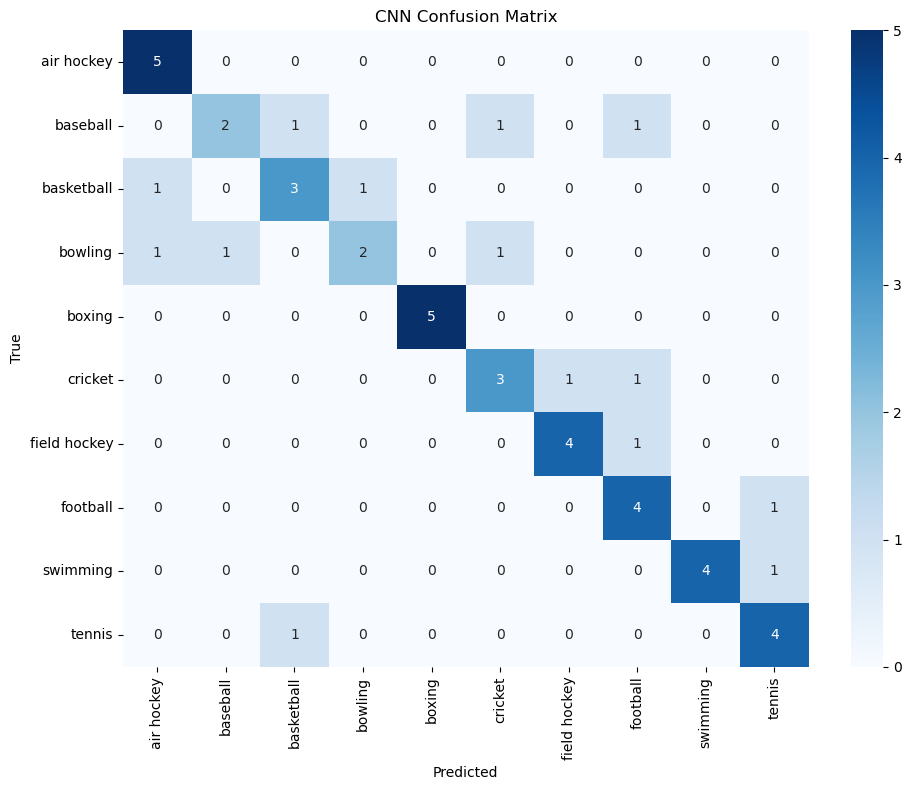

In [102]:
#CNN confusion matrix
cm_cnn = confusion_matrix(all_true, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_cnn, annot=True, fmt="d",
            cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("CNN Confusion Matrix")
plt.tight_layout()
plt.show()


In [103]:
def train_cnn(model, train_loader, val_loader, criterion, optimizer, epochs=10):
    train_loss_hist, val_loss_hist = [], []
    train_acc_hist,  val_acc_hist  = [], []

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        running_correct = 0
        running_total = 0

        for imgs, labels in train_loader:
            imgs = imgs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * imgs.size(0)
            _, preds = outputs.max(1)
            running_correct += (preds == labels).sum().item()
            running_total += labels.size(0)

        train_loss = running_loss / running_total
        train_acc  = running_correct / running_total

        # Validation
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs = imgs.to(device)
                labels = labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * imgs.size(0)
                _, preds = outputs.max(1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_loss /= val_total
        val_acc  = val_correct / val_total

        train_loss_hist.append(train_loss)
        val_loss_hist.append(val_loss)
        train_acc_hist.append(train_acc)
        val_acc_hist.append(val_acc)

        print(f"Epoch {epoch:02d}/{epochs} "
              f"| Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} "
              f"| Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    return train_loss_hist, val_loss_hist, train_acc_hist, val_acc_hist


In [104]:
train_loss_hist, val_loss_hist, train_acc_hist, val_acc_hist = train_cnn(
    cnn_model, cnn_train_loader, cnn_val_loader, criterion, optimizer, epochs=10
)

Epoch 01/10 | Train Loss: 0.7492, Train Acc: 0.7408 | Val Loss: 1.5008, Val Acc: 0.5223
Epoch 02/10 | Train Loss: 0.7415, Train Acc: 0.7433 | Val Loss: 1.1497, Val Acc: 0.5945
Epoch 03/10 | Train Loss: 0.6699, Train Acc: 0.7639 | Val Loss: 1.0980, Val Acc: 0.5808
Epoch 04/10 | Train Loss: 0.6046, Train Acc: 0.8094 | Val Loss: 1.0447, Val Acc: 0.6357
Epoch 05/10 | Train Loss: 0.5780, Train Acc: 0.8000 | Val Loss: 1.0183, Val Acc: 0.6460
Epoch 06/10 | Train Loss: 0.5999, Train Acc: 0.7966 | Val Loss: 0.9745, Val Acc: 0.6529
Epoch 07/10 | Train Loss: 0.4940, Train Acc: 0.8446 | Val Loss: 1.1119, Val Acc: 0.6117
Epoch 08/10 | Train Loss: 0.4988, Train Acc: 0.8258 | Val Loss: 1.0705, Val Acc: 0.6460
Epoch 09/10 | Train Loss: 0.4374, Train Acc: 0.8609 | Val Loss: 1.0653, Val Acc: 0.6357
Epoch 10/10 | Train Loss: 0.4508, Train Acc: 0.8549 | Val Loss: 0.9673, Val Acc: 0.6598


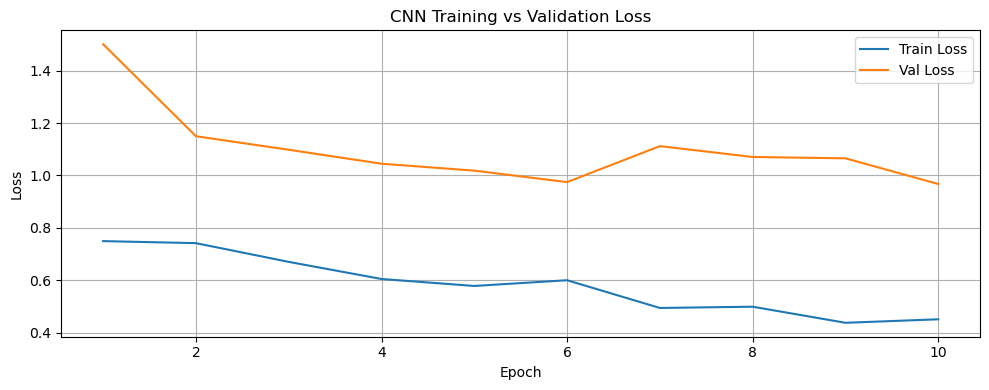

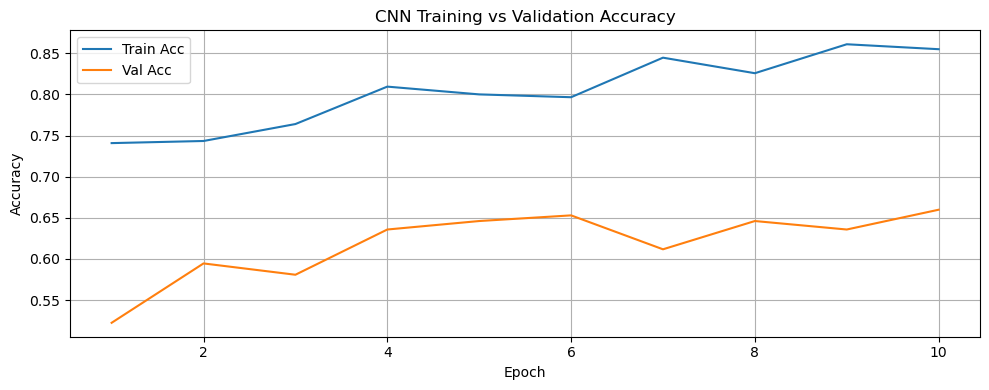

In [105]:
epochs_range = range(1, len(train_loss_hist) + 1)

plt.figure(figsize=(10, 4))
plt.plot(epochs_range, train_loss_hist, label="Train Loss")
plt.plot(epochs_range, val_loss_hist, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(epochs_range, train_acc_hist, label="Train Acc")
plt.plot(epochs_range, val_acc_hist, label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [106]:
from PIL import Image
import torch.nn.functional as F

def predict_sport_from_path(model, image_path, class_names, transform, device=device, topk=3, show=True):
    """
    Given a trained model and an image path, return the predicted sport
    and optionally show the image with predicted label.
    """
    model.eval()

    # Load and preprocess image
    img = Image.open(image_path).convert("RGB")
    img_tensor = transform(img).unsqueeze(0).to(device)  

    with torch.no_grad():
        outputs = model(img_tensor)               
        probs = F.softmax(outputs, dim=1)[0]      

    top_probs, top_indices = probs.topk(topk)
    top_probs = top_probs.cpu().numpy()
    top_indices = top_indices.cpu().numpy()

    top_labels = [class_names[i] for i in top_indices]

    # Print results
    print(f"Top {topk} predictions for {image_path}:")
    for rank, (label, p) in enumerate(zip(top_labels, top_probs), start=1):
        print(f"{rank}. {label} (prob = {p:.3f})")

    # Optionally visualize
    if show:
        plt.figure(figsize=(3, 3))
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"Predicted: {top_labels[0]}")
        plt.tight_layout()
        plt.show()

    # Return best prediction and all top-k
    return top_labels[0], list(zip(top_labels, top_probs))


In [ ]:
import torch
import numpy as np
import torch.nn.functional as F

cnn_model.eval()

all_true = []
all_pred = []
all_probs = []   

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        outputs = cnn_model(imgs)         
        probs = F.softmax(outputs, dim=1) 
        _, preds = outputs.max(1)         

        all_true.extend(labels.cpu().numpy())
        all_pred.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_true = np.array(all_true)
all_pred = np.array(all_pred)
all_probs = np.array(all_probs)

print("Shape of all_true:", all_true.shape)
print("Shape of all_pred:", all_pred.shape)
print("Shape of all_probs:", all_probs.shape)

Shape of all_true: (50,)
Shape of all_pred: (50,)
Shape of all_probs: (50, 10)


In [108]:
pred_sport_names = [class_names[i] for i in all_pred]
true_sport_names = [class_names[i] for i in all_true]

for i in range(10):
    print(f"Example {i}: True = {true_sport_names[i]}, Pred = {pred_sport_names[i]}")


Example 0: True = air hockey, Pred = air hockey
Example 1: True = air hockey, Pred = air hockey
Example 2: True = air hockey, Pred = air hockey
Example 3: True = air hockey, Pred = air hockey
Example 4: True = air hockey, Pred = air hockey
Example 5: True = baseball, Pred = basketball
Example 6: True = baseball, Pred = cricket
Example 7: True = baseball, Pred = baseball
Example 8: True = baseball, Pred = baseball
Example 9: True = baseball, Pred = baseball


In [109]:
import torch

def compute_accuracy(model, loader, device):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            labels = labels.to(device)

            outputs = model(imgs)
            _, preds = outputs.max(1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    acc = correct / total
    print(f"Test accuracy: {acc:.4f}")
    return acc


In [110]:
test_acc = compute_accuracy(cnn_model, test_loader, device)


Test accuracy: 0.7400


In [111]:
import matplotlib.pyplot as plt

def show_test_predictions(model, loader, class_names, device, n_images=24):
    """
    Display images from the test set with predicted (and true) labels.
    Green title = correct prediction, Red title = incorrect.
    Also prints overall test accuracy.
    """
    acc = compute_accuracy(model, loader, device)
    print(f"Overall test accuracy (on full test set): {acc:.4f}\n")

    model.eval()
    images_shown = 0
    cols = 4
    rows = n_images // cols + int(n_images % cols != 0)
    
    plt.figure(figsize=(3 * cols, 3 * rows))

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            labels = labels.to(device)

            outputs = model(imgs)
            _, preds = outputs.max(1)

            for i in range(imgs.size(0)):
                if images_shown >= n_images:
                    plt.tight_layout()
                    plt.show()
                    return

                images_shown += 1

                img_np = imgs[i].cpu().permute(1, 2, 0).numpy()
                true_label = class_names[labels[i].item()]
                pred_label = class_names[preds[i].item()]
                correct = (labels[i] == preds[i]).item()

                plt.subplot(rows, cols, images_shown)
                plt.imshow(img_np)
                plt.axis("off")

                title_color = "green" if correct else "red"
                plt.title(f"Pred: {pred_label}\nTrue: {true_label}",
                          color=title_color, fontsize=8)

    plt.tight_layout()
    plt.show()


Test accuracy: 0.7400
Overall test accuracy (on full test set): 0.7400



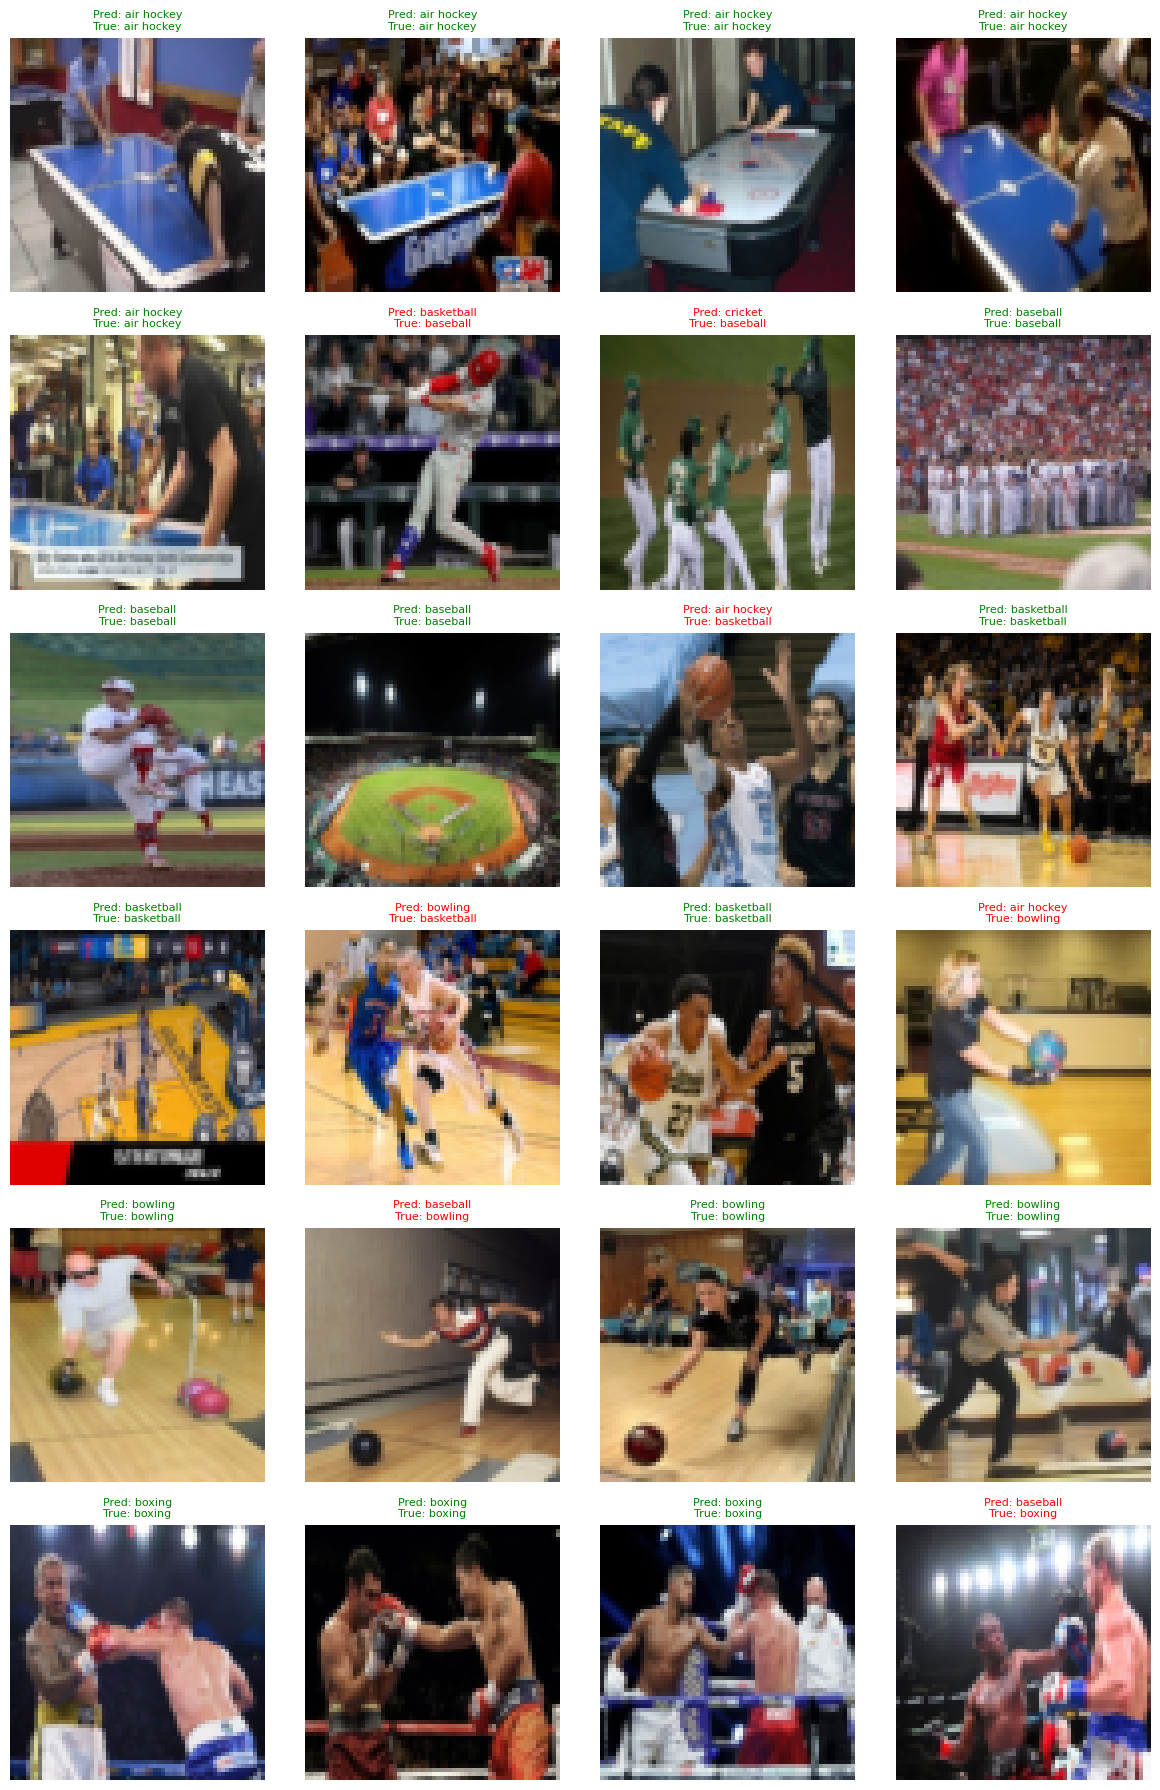

In [112]:
show_test_predictions(cnn_model, test_loader, class_names, device, n_images=24)
